In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Lottery/lottotexas.csv', header=None)

winning_number_columns = [4, 5, 6, 7, 8, 9]

print(df.head()) 

    

             0   1   2     3   4   5   6   7   8   9
0  Lotto Texas  11  14  1992  13  16  22  29  32  36
1  Lotto Texas  11  18  1992  27  31  39  44  45  47
2  Lotto Texas  11  21  1992  11  21  24  28  31  46
3  Lotto Texas  11  25  1992  14  21  36  39  40  42
4  Lotto Texas  11  28  1992   9  17  21  24  28  50


<Axes: >

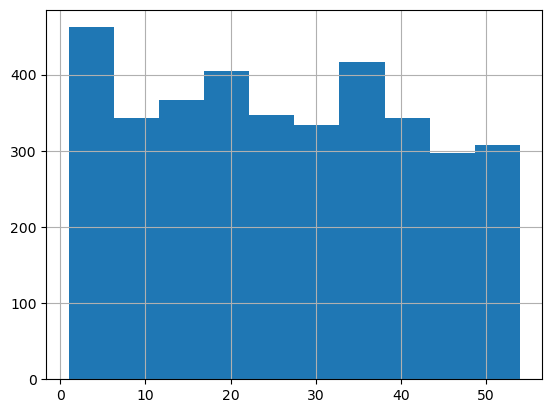

In [2]:
df[4].hist()

In [3]:
df[4].min()

1

In [4]:
most_frequent = df[4].value_counts()
print(most_frequent)

4
4     91
18    89
39    89
26    83
32    82
19    80
5     78
1     78
14    76
12    76
8     76
13    76
38    75
35    75
43    73
27    72
28    72
34    72
6     72
3     72
23    71
2     71
15    70
11    70
33    69
16    68
42    66
7     66
9     66
20    66
44    66
24    65
36    65
10    65
50    64
46    61
37    61
29    61
49    60
30    60
17    60
31    59
45    59
40    58
41    57
47    56
25    56
21    55
48    55
53    55
22    54
51    48
52    42
54    39
Name: count, dtype: int64


In [5]:
df[4]


0       13
1       27
2       11
3       14
4        9
        ..
3616     7
3617    54
3618    18
3619    53
3620    38
Name: 4, Length: 3621, dtype: int64

In [6]:
print('most probable')

for idx, col in enumerate(winning_number_columns, start=1):
    top_num = df[col].value_counts().head(5)

    print(f"Position {idx} (Column {col}):")
    print(top_num.sort_values(ascending=False))
    print()

most probable
Position 1 (Column 4):
4
4     91
18    89
39    89
26    83
32    82
Name: count, dtype: int64

Position 2 (Column 5):
5
8     90
13    82
10    82
1     81
44    80
Name: count, dtype: int64

Position 3 (Column 6):
6
31    88
29    87
9     82
21    82
36    81
Name: count, dtype: int64

Position 4 (Column 7):
7
42    92
31    91
4     83
35    82
39    79
Name: count, dtype: int64

Position 5 (Column 8):
8
21    88
44    88
40    86
26    82
38    82
Name: count, dtype: int64

Position 6 (Column 9):
9
19    97
49    85
37    83
16    83
12    79
Name: count, dtype: int64



In [9]:
# Extract the last 6 columns (winning numbers)
winning_numbers = df.iloc[:, 4:10]

# Convert each row of winning numbers to a tuple (so they can be counted)
combos = winning_numbers.apply(lambda row: tuple(sorted(row)), axis=1)

# Count frequency of each unique combination
combo_counts = combos.value_counts()

# Get the top 5 most frequent combinations
top_5_combos = combo_counts.head(10)

# Print results
print("Top 5 most frequent 6-number combinations:\n")
for combo, count in top_5_combos.items():
    print(f"Combination: {combo}, Frequency: {count}")


Top 5 most frequent 6-number combinations:

Combination: (13, 16, 22, 29, 32, 36), Frequency: 1
Combination: (15, 18, 40, 41, 45, 48), Frequency: 1
Combination: (10, 26, 28, 31, 37, 45), Frequency: 1
Combination: (6, 22, 34, 35, 41, 48), Frequency: 1
Combination: (20, 22, 23, 29, 39, 54), Frequency: 1
Combination: (4, 11, 16, 17, 27, 34), Frequency: 1
Combination: (1, 5, 14, 35, 37, 42), Frequency: 1
Combination: (6, 21, 22, 27, 39, 44), Frequency: 1
Combination: (7, 10, 12, 22, 40, 42), Frequency: 1
Combination: (9, 15, 18, 40, 43, 50), Frequency: 1


In [10]:
print(combo_counts)

(13, 16, 22, 29, 32, 36)    1
(15, 18, 40, 41, 45, 48)    1
(10, 26, 28, 31, 37, 45)    1
(6, 22, 34, 35, 41, 48)     1
(20, 22, 23, 29, 39, 54)    1
                           ..
(6, 9, 12, 31, 33, 35)      1
(5, 20, 22, 24, 27, 40)     1
(1, 7, 13, 19, 20, 44)      1
(12, 15, 19, 28, 37, 40)    1
(9, 16, 24, 38, 40, 48)     1
Name: count, Length: 3621, dtype: int64


In [15]:
import random

# Constants
LOTTO_MIN = 1
LOTTO_MAX = 54
NUMBERS_PER_DRAW = 6
NUM_COMBOS_NEEDED = 5


In [16]:
# Extract past winning combinations
past_combos = df.iloc[:, 4:10].apply(lambda row: tuple(sorted(row)), axis=1)
seen_combos = set(past_combos)

In [17]:
# Generate new unique combinations
new_combos = set()

while len(new_combos) < NUM_COMBOS_NEEDED:
    combo = tuple(sorted(random.sample(range(LOTTO_MIN, LOTTO_MAX + 1), NUMBERS_PER_DRAW)))
    if combo not in seen_combos and combo not in new_combos:
        new_combos.add(combo)

# Print new combinations
print("5 unique 6-number combinations that have never occurred in the dataset:\n")
for combo in sorted(new_combos):
    print(combo)
    

5 unique 6-number combinations that have never occurred in the dataset:

(2, 23, 30, 34, 45, 51)
(6, 20, 22, 28, 38, 43)
(8, 19, 21, 27, 48, 50)
(9, 18, 27, 31, 43, 47)
(9, 20, 36, 37, 53, 54)


In [ ]:
#generate 5 unique combinations that never occurred in the dataset. 
#make sure to take most frequent (most probable) numbers for each of the last 6 columns into account

In [19]:
import itertools
import random

# Extract the last 6 columns (winning numbers: columns 4 to 9 inclusive)
winning_numbers = df.iloc[:, 4:10]

# Get all historical combinations as sorted tuples
existing_combos = set(winning_numbers.apply(lambda row: tuple(sorted(row)), axis=1))

# Get top N frequent numbers for each column position (N can be tweaked)
N = 10
top_numbers_per_position = []

for col in winning_numbers.columns:
    top_numbers = winning_numbers[col].value_counts().head(N).index.tolist()
    top_numbers_per_position.append(top_numbers)

# Generate candidate combinations using Cartesian product of top numbers per position
# Each generated combo respects the original column-wise frequency
candidate_combos = list(itertools.product(*top_numbers_per_position))

# Normalize combos to sorted tuple (to match existing_combos format)
normalized_new_combos = [tuple(sorted(combo)) for combo in candidate_combos]

# Remove any combinations that already occurred
unique_new_combos = list(set(normalized_new_combos) - existing_combos)

# Shuffle for randomness
random.shuffle(unique_new_combos)

# Get first 5 unique new combos
top_5_new_combos = unique_new_combos[:5]

# Print the new probable but unseen combinations
print("5 new unique and probable 6-number combinations that have never occurred:\n")
for combo in top_5_new_combos:
    print(combo)


5 new unique and probable 6-number combinations that have never occurred:

(8, 12, 13, 16, 18, 42)
(8, 11, 39, 40, 41, 41)
(4, 22, 26, 29, 37, 42)
(1, 19, 31, 31, 38, 43)
(6, 21, 26, 26, 36, 44)
